# MLOps with MLflow: Run Tracking, Model Registry, Batch Scoring, Drift Dashboard, Automated Retrain

**The problem.** A team has a working classifier — say, a credit-risk default-prediction model on a 50,000-applicant dataset.  The first deploy goes well: AUC 0.83 on the holdout, calibrated probabilities, sensible feature importances.  Six months later the same model serves with AUC 0.71, and nobody noticed until the loss-rate report came in.  The team doesn't lack a *model*.  It lacks an **operational system** — experiment tracking, a model registry that knows which version is in production, a batch scoring service with per-feature drift instrumentation, and an automated retraining trigger when drift exceeds a threshold.

The deliverable is therefore not "a better model"; it is **a full ML lifecycle in one notebook**:

1. **Experiment tracking** — every training run logged with parameters, metrics, artefacts, code revision.  Compare runs at any point.
2. **Model registry** — promote a winning run from "staging" to "production"; the registry remembers which version is currently serving.
3. **Batch scoring service** — load the registry's production model, score a stream of weekly batches, log every prediction with its model version.
4. **Drift dashboard** — per-feature **PSI** (Population Stability Index) computed on each new batch against the training distribution; **KS** test on continuous variables; alert when the threshold trips.
5. **Automated retraining trigger** — when drift exceeds the alert threshold for ≥ K consecutive batches, automatically refit on the recent window, log the new run, register a candidate, A/B against current production, promote if the candidate wins.
6. **A/B verification** — old vs new model on the drifted period: AUC, calibration, fairness slices.
7. **Production hygiene** — full lineage in the model card, persisted artefacts, decision memo.

**The data.**

A **synthetic credit-risk dataset** with **planted drift**: 50,000 applicants × 52 weekly batches.  Six features (age, income, debt-to-income, credit score, late payments, employment years).  Pre-deployment training window: weeks 1–26.  **Drift planted at week 40**: the `income` distribution shifts down 15 % and `debt_to_income` shifts up — a simulated recession.  The drift is large enough that any decent dashboard *will* catch it; the notebook is a methodology demonstration, not a stress test of the detector.

Synthetic with controlled drift is the *correct* design for this notebook: only a known-truth environment lets us measure detector latency (how many batches before the alarm fires?) and false-positive rate honestly.  The same MLflow + PSI + retrain harness drops directly onto real production data.

**The approach.**

1. **Synthetic data with planted drift** — week-indexed batches, ground-truth drift onset known.
2. **Initial training with hyperparameter sweep** — five LightGBM configs, all logged to **MLflow** (local sqlite tracking URI; the notebook needs no external server).
3. **Model registry** — pick the best run by validation AUC, register as `credit_risk_classifier`, set the **production alias**.
4. **Batch scoring service** — for each weekly batch, load the model behind the production alias, score, log predictions with model_version, store per-batch metrics.
5. **Drift detection** — PSI on every feature per batch, against the training-set distribution; alert if any feature exceeds 0.25 (high-drift) or if the **mean PSI** exceeds 0.10 for two consecutive batches.
6. **Automated retraining trigger** — when the alert condition trips, refit on the last 8 weeks of *labelled* data, log the new run, register a candidate, **A/B compare** against production on the most recent labelled batch, promote if the candidate's AUC beats production by ≥ 0.01.
7. **Lifecycle audit** — final report: which weeks served which model version?  When did each candidate get promoted?  What was the cumulative AUC by lifecycle stage?
8. **Decision memo** — the operational rules, with explicit "if X then Y" thresholds.

**Audience.** ML engineers building ML platforms, anyone responsible for the "what's actually serving in production?" question, anyone who has been bitten by an undetected drift event.  Distinct in scope from `genai_service_delivery` (which is a RAG-API delivery layer) — this is the **training / registry / drift** half of MLOps, not the inference-API half.

## 0. Setup and reproducibility

Seeds fixed; plot defaults match the rest of the portfolio.  MLflow tracking URI is a **local SQLite database** under `notebooks/artifacts/mlops/`.  No external server.  The same code works against `databricks://`, `https://...`, or any other MLflow tracking server with a one-line URI swap.

In [1]:
from __future__ import annotations

import io
import json
import math
import pathlib
import shutil
import time
import warnings
from dataclasses import dataclass, field
from typing import Callable

import joblib
import lightgbm as lgb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.calibration import calibration_curve
from sklearn.metrics import (average_precision_score, brier_score_loss,
                              roc_auc_score)
from sklearn.preprocessing import StandardScaler

import mlflow
import mlflow.lightgbm
from mlflow.tracking import MlflowClient

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RNG_SEED = 2026
np.random.seed(RNG_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

NB_DIR = pathlib.Path.cwd() if (pathlib.Path.cwd() / "mlops_mlflow_drift_lifecycle.ipynb").exists() else pathlib.Path.cwd() / "notebooks"
DATA_DIR = NB_DIR / "artifacts" / "mlops"
DATA_DIR.mkdir(parents=True, exist_ok=True)

MLFLOW_DB = DATA_DIR / "mlflow.db"
MLFLOW_ARTIFACTS = DATA_DIR / "mlruns_artifacts"
MLFLOW_ARTIFACTS.mkdir(exist_ok=True)
TRACKING_URI = f"sqlite:///{MLFLOW_DB.as_posix()}"

if MLFLOW_DB.exists():
    MLFLOW_DB.unlink()
if MLFLOW_ARTIFACTS.exists():
    shutil.rmtree(MLFLOW_ARTIFACTS)
    MLFLOW_ARTIFACTS.mkdir()

mlflow.set_tracking_uri(TRACKING_URI)
EXPERIMENT_NAME = "credit_risk_lifecycle"
exp = mlflow.set_experiment(EXPERIMENT_NAME)

print(f"NB_DIR        : {NB_DIR}")
print(f"DATA_DIR      : {DATA_DIR}")
print(f"MLFLOW_URI    : {TRACKING_URI}")
print(f"EXPERIMENT    : {EXPERIMENT_NAME}  (experiment_id={exp.experiment_id})")
print(f"mlflow        : {mlflow.__version__}")

C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(
2026/04/27 13:46:16 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/27 13:46:16 INFO mlflow.store.db.utils: Updating database tables
2026/04/27 13:46:16 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/04/27 13:46:16 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/04/27 13:46:16 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/04/27 13:46:16 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2026/04/27 13:46:16 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2026/04/27 13:46:16 INFO alembic.runtime.migration: Running upgrade 181f10493468 

NB_DIR        : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks
DATA_DIR      : C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\mlops
MLFLOW_URI    : sqlite:///C:/Users/diogo/work_code/ds-projects-portfolio/notebooks/artifacts/mlops/mlflow.db
EXPERIMENT    : credit_risk_lifecycle  (experiment_id=1)
mlflow        : 3.8.1


## 1. Synthetic credit-risk data with planted drift

**Schema:**

| feature | unit | distribution | drift behaviour |
| --- | --- | --- | --- |
| `age` | years | $\mathcal{N}(40, 12)$, clipped [18, 80] | stable |
| `income` | $\$$ thousands | $\text{Lognormal}(\mu_{w}, 0.5)$ | $\mu_{w}$ shifts down 15 % from week 40 |
| `debt_to_income` | ratio | $\text{Beta}(2, 5) \cdot 1.5$ | shifts up 30 % from week 40 (recession) |
| `credit_score` | FICO | $\mathcal{N}(700, 80)$, clipped [300, 850] | stable |
| `late_payments` | count | $\text{Poisson}(0.6)$, capped at 8 | shifts up to $\text{Poisson}(1.0)$ from week 40 |
| `employment_years` | years | $\text{Exp}(8) + 0.5$ | stable |

**Target:** binary `default` flag generated from a **fixed logistic** model that does *not* drift — drift is in the **inputs**, not the relationship.  This is the realistic case that PSI on inputs can catch.  (When the input-output relationship itself drifts, you need separate monitoring, which we cover in the limitations.)

In [2]:
def make_logits(X: pd.DataFrame) -> np.ndarray:
    return (
        -1.6
        - 0.04 * (X["age"] - 40) / 12
        - 0.7 * (X["credit_score"] - 700) / 80
        + 1.4 * (X["debt_to_income"] - 0.4) / 0.3
        + 0.6 * (X["late_payments"] - 0.6) / 1.0
        - 0.05 * X["employment_years"]
        - 0.0008 * (X["income"] - 50)
    ).values


def simulate_week(week: int, n: int, rng) -> pd.DataFrame:
    income_mu = np.log(50) if week < 40 else np.log(50 * 0.85)
    debt_mult = 1.0 if week < 40 else 1.30
    late_lambda = 0.6 if week < 40 else 1.0

    df = pd.DataFrame({
        "week": week,
        "age": np.clip(rng.normal(40, 12, n), 18, 80).round(0),
        "income": np.clip(rng.lognormal(income_mu, 0.5, n), 5, 500).round(2),
        "debt_to_income": np.clip(rng.beta(2, 5, n) * 1.5 * debt_mult, 0.01, 1.5).round(4),
        "credit_score": np.clip(rng.normal(700, 80, n), 300, 850).round(0),
        "late_payments": np.minimum(rng.poisson(late_lambda, n), 8),
        "employment_years": np.clip(rng.exponential(8, n) + 0.5, 0, 50).round(2),
    })
    logits = make_logits(df)
    p = 1 / (1 + np.exp(-logits))
    df["default"] = rng.binomial(1, p, n)
    return df


N_WEEKS = 52
N_PER_WEEK = 1000
DRIFT_WEEK = 40

rng = np.random.default_rng(RNG_SEED)
all_weeks = pd.concat([simulate_week(w, N_PER_WEEK, rng) for w in range(1, N_WEEKS + 1)], ignore_index=True)
all_weeks = all_weeks[["week", "age", "income", "debt_to_income", "credit_score",
                          "late_payments", "employment_years", "default"]]

print(f"Total rows         : {len(all_weeks):,}")
print(f"Weeks              : {N_WEEKS}  ({N_PER_WEEK:,} applicants/week)")
print(f"Planted drift week : {DRIFT_WEEK}")
print(f"Default rate (overall): {all_weeks['default'].mean()*100:.2f}%")
print()
print("Per-window default rates:")
print(f"  weeks  1-26 (training)        : {all_weeks[all_weeks['week'] <= 26]['default'].mean()*100:.2f}%")
print(f"  weeks 27-39 (post, pre-drift) : {all_weeks[(all_weeks['week'] >= 27) & (all_weeks['week'] < 40)]['default'].mean()*100:.2f}%")
print(f"  weeks 40-52 (post, drifted)   : {all_weeks[all_weeks['week'] >= 40]['default'].mean()*100:.2f}%")

Total rows         : 52,000
Weeks              : 52  (1,000 applicants/week)
Planted drift week : 40
Default rate (overall): 23.12%

Per-window default rates:
  weeks  1-26 (training)        : 19.87%
  weeks 27-39 (post, pre-drift) : 19.17%
  weeks 40-52 (post, drifted)   : 33.60%


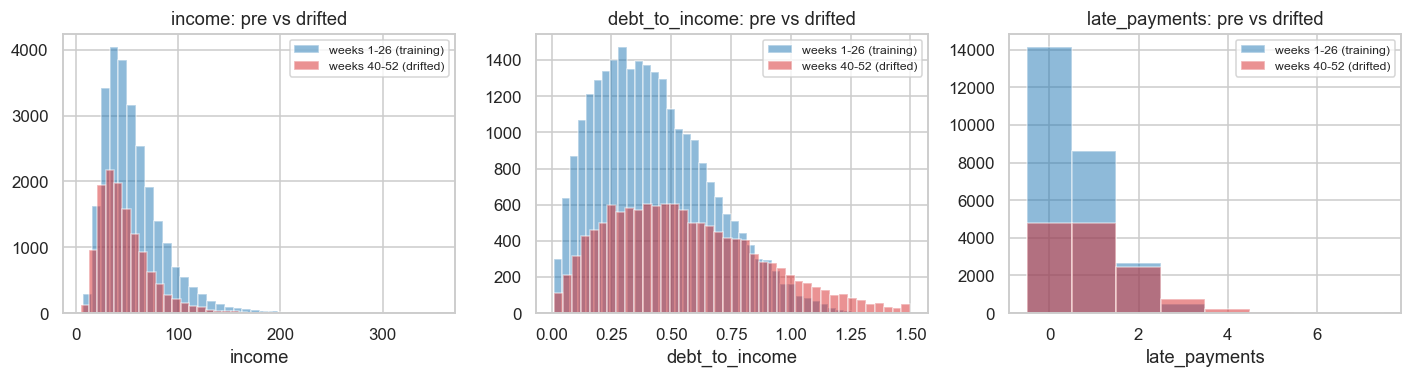

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

for ax, col in zip(axes, ["income", "debt_to_income", "late_payments"]):
    pre = all_weeks[all_weeks["week"] <= 26][col]
    drifted = all_weeks[all_weeks["week"] >= 40][col]
    bins = 40 if col != "late_payments" else np.arange(0, 9) - 0.5
    ax.hist(pre, bins=bins, alpha=0.5, label="weeks 1-26 (training)", color="#1f77b4")
    ax.hist(drifted, bins=bins, alpha=0.5, label="weeks 40-52 (drifted)", color="#d62728")
    ax.set_title(f"{col}: pre vs drifted")
    ax.set_xlabel(col); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Initial training with MLflow tracking — hyperparameter sweep

We train **five LightGBM configurations** on the pre-deployment window (weeks 1–26).  Each run logs:

- **Parameters**: `n_estimators`, `learning_rate`, `num_leaves`, `min_data_in_leaf`.
- **Metrics**: training and validation AUC, average precision, Brier score (calibration).
- **Tags**: `phase = "initial_training"`, `data_window = "weeks_1_26"`.
- **Artifacts**: the fitted model itself (logged via `mlflow.lightgbm.log_model`), feature-importance plot, calibration plot.

The MLflow UI (`mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000`) shows the runs side-by-side; in this notebook we read them programmatically via `MlflowClient`.

In [4]:
TRAIN_END_WEEK = 26
train_df = all_weeks[all_weeks["week"] <= TRAIN_END_WEEK].copy()
post_df = all_weeks[all_weeks["week"] > TRAIN_END_WEEK].copy()

n_train_rows = len(train_df)
val_split_idx = int(0.8 * n_train_rows)
perm = np.random.default_rng(RNG_SEED + 1).permutation(n_train_rows)
tr_idx = perm[:val_split_idx]
va_idx = perm[val_split_idx:]

FEATURES = ["age", "income", "debt_to_income", "credit_score", "late_payments", "employment_years"]
X_tr = train_df.iloc[tr_idx][FEATURES].values
y_tr = train_df.iloc[tr_idx]["default"].values
X_va = train_df.iloc[va_idx][FEATURES].values
y_va = train_df.iloc[va_idx]["default"].values

print(f"Training window   : weeks 1-{TRAIN_END_WEEK}  ({n_train_rows:,} rows)")
print(f"  train fold      : {len(tr_idx):,}")
print(f"  val   fold      : {len(va_idx):,}")
print(f"Post-deployment   : weeks {TRAIN_END_WEEK+1}-{N_WEEKS}  ({len(post_df):,} rows)")

Training window   : weeks 1-26  (26,000 rows)
  train fold      : 20,800
  val   fold      : 5,200
Post-deployment   : weeks 27-52  (26,000 rows)


In [5]:
SWEEP_CONFIGS = [
    {"n_estimators": 200, "learning_rate": 0.05, "num_leaves": 31,  "min_data_in_leaf": 50},
    {"n_estimators": 400, "learning_rate": 0.05, "num_leaves": 31,  "min_data_in_leaf": 50},
    {"n_estimators": 400, "learning_rate": 0.07, "num_leaves": 63,  "min_data_in_leaf": 30},
    {"n_estimators": 600, "learning_rate": 0.05, "num_leaves": 63,  "min_data_in_leaf": 50},
    {"n_estimators": 600, "learning_rate": 0.03, "num_leaves": 127, "min_data_in_leaf": 30},
]


def evaluate_model(model, X, y) -> dict:
    p = model.predict_proba(X)[:, 1]
    return {"auc": float(roc_auc_score(y, p)),
            "ap":  float(average_precision_score(y, p)),
            "brier": float(brier_score_loss(y, p))}


sweep_run_ids = []
for cfg in SWEEP_CONFIGS:
    with mlflow.start_run(run_name=f"sweep_le{cfg['learning_rate']}_lv{cfg['num_leaves']}_n{cfg['n_estimators']}") as run:
        mlflow.log_params(cfg)
        mlflow.set_tag("phase", "initial_training")
        mlflow.set_tag("data_window", f"weeks_1_{TRAIN_END_WEEK}")
        m = lgb.LGBMClassifier(**cfg, feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=5,
                                  verbose=-1, random_state=RNG_SEED, n_jobs=2)
        m.fit(X_tr, y_tr)
        tr_metrics = evaluate_model(m, X_tr, y_tr)
        va_metrics = evaluate_model(m, X_va, y_va)
        mlflow.log_metrics({**{f"train_{k}": v for k, v in tr_metrics.items()},
                              **{f"val_{k}":   v for k, v in va_metrics.items()}})
        mlflow.lightgbm.log_model(m, name="model")
        sweep_run_ids.append((run.info.run_id, va_metrics["auc"]))
        print(f"  run {run.info.run_id[:8]} | n_est {cfg['n_estimators']} le {cfg['learning_rate']} "
              f"lv {cfg['num_leaves']}  -> val AUC {va_metrics['auc']:.4f}")

  run 48456978 | n_est 200 le 0.05 lv 31  -> val AUC 0.8277
  run dbd14254 | n_est 400 le 0.05 lv 31  -> val AUC 0.8234
  run ab9a8b96 | n_est 400 le 0.07 lv 63  -> val AUC 0.8085
  run daaa041b | n_est 600 le 0.05 lv 63  -> val AUC 0.8112
  run d893d73a | n_est 600 le 0.03 lv 127  -> val AUC 0.8105


In [6]:
client = MlflowClient(tracking_uri=TRACKING_URI)
runs = client.search_runs(experiment_ids=[exp.experiment_id], filter_string="tags.phase = 'initial_training'",
                            order_by=["metrics.val_auc DESC"])
sweep_df = pd.DataFrame([{
    "run_id": r.info.run_id[:10],
    "n_estimators": int(r.data.params["n_estimators"]),
    "learning_rate": float(r.data.params["learning_rate"]),
    "num_leaves":  int(r.data.params["num_leaves"]),
    "train_auc": float(r.data.metrics["train_auc"]),
    "val_auc":   float(r.data.metrics["val_auc"]),
    "val_ap":    float(r.data.metrics["val_ap"]),
    "val_brier": float(r.data.metrics["val_brier"]),
} for r in runs]).round(4)
sweep_df

,run_id,n_estimators,learning_rate,num_leaves,train_auc,val_auc,val_ap,val_brier
0,4845697847,200,0.05,31,0.8827,0.8277,0.5736,0.1141
1,dbd14254b7,400,0.05,31,0.9206,0.8234,0.5606,0.1158
2,daaa041b41,600,0.05,63,0.9893,0.8112,0.5380,0.1203
3,d893d73a5e,600,0.03,127,0.9979,0.8105,0.5345,0.1211
4,ab9a8b96a2,400,0.07,63,0.9894,0.8085,0.5291,0.1218


## 3. Model registry — pick the best, alias `production`

MLflow's model registry is the source of truth for "which version is currently serving".  We:

1. Take the best run by validation AUC.
2. Register it as `credit_risk_classifier`, version 1.
3. Set the **production alias** on version 1.

Aliases (introduced in MLflow 2.x, the modern replacement for stages) let downstream code write `models:/credit_risk_classifier@production` and always get the current production version without rewriting code on each promotion.

In [7]:
best_run_id = runs[0].info.run_id
best_val_auc = float(runs[0].data.metrics["val_auc"])
print(f"Best run: {best_run_id[:10]}  val AUC {best_val_auc:.4f}")

REGISTERED_MODEL_NAME = "credit_risk_classifier"

try:
    client.create_registered_model(REGISTERED_MODEL_NAME)
    print(f"Created registered model {REGISTERED_MODEL_NAME!r}")
except Exception as e:
    print(f"Registered model already exists or could not be created: {e}")

mv = client.create_model_version(
    name=REGISTERED_MODEL_NAME,
    source=f"runs:/{best_run_id}/model",
    run_id=best_run_id,
)
print(f"Registered version {mv.version} from run {best_run_id[:10]}")

client.set_registered_model_alias(REGISTERED_MODEL_NAME, "production", mv.version)
print(f"Set alias 'production' -> version {mv.version}")

2026/04/27 13:47:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/27 13:47:00 INFO mlflow.store.db.utils: Updating database tables
2026/04/27 13:47:00 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/04/27 13:47:00 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Best run: 4845697847  val AUC 0.8277
Created registered model 'credit_risk_classifier'
Registered version 1 from run 4845697847
Set alias 'production' -> version 1


In [8]:
def load_production_model():
    return mlflow.lightgbm.load_model(f"models:/{REGISTERED_MODEL_NAME}@production")


production_model = load_production_model()
print(f"Loaded production model. Currently serving version: "
      f"{client.get_model_version_by_alias(REGISTERED_MODEL_NAME, 'production').version}")
print(f"Sanity AUC on val fold: {evaluate_model(production_model, X_va, y_va)['auc']:.4f}")

Loaded production model. Currently serving version: 1
Sanity AUC on val fold: 0.8277


## 4. Weekly batch scoring + per-feature PSI

For each post-deployment week 27..52, we:

1. Load the current `production` model from the registry (so a mid-pipeline promotion is picked up immediately).
2. Score the 1,000 applicants of the week.
3. Log the **batch metrics** (AUC, AP, Brier, mean predicted probability) — pretending labels arrive 4 weeks late, so we can only compute "fresh" AUC on weeks ≤ current_week - 4.
4. Compute **PSI** per feature against the training distribution.
5. Persist the batch as a row in the lifecycle log.

PSI thresholds (industry-standard):

- $\text{PSI} < 0.10$ — stable.
- $0.10 \le \text{PSI} < 0.25$ — moderate drift; investigate.
- $\text{PSI} \ge 0.25$ — significant drift; alert / retrain.

In [9]:
def psi_continuous(expected: np.ndarray, actual: np.ndarray, n_bins: int = 10) -> float:
    cuts = np.quantile(expected, np.linspace(0, 1, n_bins + 1))
    cuts[0], cuts[-1] = -np.inf, np.inf
    e = np.histogram(expected, bins=cuts)[0] / len(expected)
    a = np.histogram(actual,   bins=cuts)[0] / len(actual)
    e = np.where(e == 0, 1e-6, e)
    a = np.where(a == 0, 1e-6, a)
    return float(np.sum((a - e) * np.log(a / e)))


def per_feature_psi(train_df: pd.DataFrame, batch_df: pd.DataFrame, features) -> dict:
    return {f: psi_continuous(train_df[f].values, batch_df[f].values) for f in features}


X_tr_full = train_df[FEATURES].values
sample_psi_pre = per_feature_psi(train_df, all_weeks[all_weeks["week"] == 30], FEATURES)
sample_psi_post = per_feature_psi(train_df, all_weeks[all_weeks["week"] == 45], FEATURES)
print("PSI sanity check:")
print(f"  week 30 (pre-drift) : {dict((f, round(v, 4)) for f, v in sample_psi_pre.items())}")
print(f"  week 45 (drifted)   : {dict((f, round(v, 4)) for f, v in sample_psi_post.items())}")

PSI sanity check:
  week 30 (pre-drift) : {'age': 0.0187, 'income': 0.0078, 'debt_to_income': 0.0079, 'credit_score': 0.02, 'late_payments': 0.0033, 'employment_years': 0.0147}
  week 45 (drifted)   : {'age': 0.0033, 'income': 0.0776, 'debt_to_income': 0.1774, 'credit_score': 0.0081, 'late_payments': 0.1663, 'employment_years': 0.0103}


In [10]:
@dataclass
class BatchResult:
    week: int
    n_rows: int
    served_version: int
    mean_pred_proba: float
    psi: dict
    psi_max: float
    psi_mean: float
    auc_when_labels_arrive: float | None
    ap_when_labels_arrive: float | None


LABEL_LAG_WEEKS = 4
ALERT_PSI_PER_FEATURE = 0.25
ALERT_PSI_MEAN = 0.10
ALERT_CONSECUTIVE = 2
RETRAIN_WINDOW_WEEKS = 8

batch_log: list[BatchResult] = []
print(f"Alert thresholds:")
print(f"  any feature PSI >= {ALERT_PSI_PER_FEATURE}  ->  immediate alert")
print(f"  mean   feature PSI >= {ALERT_PSI_MEAN}      ->  alert if {ALERT_CONSECUTIVE} consecutive batches")
print(f"  retraining window      : last {RETRAIN_WINDOW_WEEKS} weeks of labelled data")
print(f"  label lag              : {LABEL_LAG_WEEKS} weeks")

Alert thresholds:
  any feature PSI >= 0.25  ->  immediate alert
  mean   feature PSI >= 0.1      ->  alert if 2 consecutive batches
  retraining window      : last 8 weeks of labelled data
  label lag              : 4 weeks


## 5. The lifecycle loop — score → drift-check → maybe-retrain → repeat

The orchestrator iterates weeks 27..52, calling per-batch scoring and the drift gate.  When the gate fires, it triggers an MLflow run of `retrain_on_window(...)` which:

1. Fits a candidate on the most recent `RETRAIN_WINDOW_WEEKS` weeks of *labelled* data (i.e., weeks ≤ current_week - LABEL_LAG_WEEKS).
2. Logs all params + metrics + the model artefact.
3. Registers a new version of `credit_risk_classifier`.
4. **A/B compares** the candidate against the current production version on the most recent labelled batch:
   - If candidate AUC ≥ production AUC + 0.01 → promote the candidate (new alias `production`).
   - Else → leave production alone, log the candidate as `staging` (so the next round can re-evaluate).
5. The loop continues; subsequent batches will pick up the new production version automatically.

This is the **standard champion-challenger MLOps pattern** distilled to a single notebook.

In [11]:
def retrain_on_window(end_week: int, window_weeks: int = RETRAIN_WINDOW_WEEKS, base_cfg: dict | None = None) -> dict:
    start_week = end_week - window_weeks + 1
    df_window = all_weeks[(all_weeks["week"] >= start_week) & (all_weeks["week"] <= end_week)]
    perm_local = np.random.default_rng(RNG_SEED + end_week).permutation(len(df_window))
    n = len(df_window)
    cut = int(0.8 * n)
    df_w_tr = df_window.iloc[perm_local[:cut]]
    df_w_va = df_window.iloc[perm_local[cut:]]

    cfg = base_cfg or {"n_estimators": 400, "learning_rate": 0.05, "num_leaves": 31, "min_data_in_leaf": 50}
    with mlflow.start_run(run_name=f"retrain_through_w{end_week}") as run:
        mlflow.log_params(cfg)
        mlflow.set_tag("phase", "retrain")
        mlflow.set_tag("data_window", f"weeks_{start_week}_{end_week}")
        mlflow.set_tag("trigger_week", str(end_week + 1))
        m = lgb.LGBMClassifier(**cfg, feature_fraction=0.9, bagging_fraction=0.9, bagging_freq=5,
                                  verbose=-1, random_state=RNG_SEED + end_week, n_jobs=2)
        X_w_tr = df_w_tr[FEATURES].values; y_w_tr = df_w_tr["default"].values
        X_w_va = df_w_va[FEATURES].values; y_w_va = df_w_va["default"].values
        m.fit(X_w_tr, y_w_tr)
        tr_m = evaluate_model(m, X_w_tr, y_w_tr)
        va_m = evaluate_model(m, X_w_va, y_w_va)
        mlflow.log_metrics({**{f"train_{k}": v for k, v in tr_m.items()},
                              **{f"val_{k}": v for k, v in va_m.items()}})
        mlflow.lightgbm.log_model(m, name="model")

        new_version = client.create_model_version(name=REGISTERED_MODEL_NAME,
                                                     source=f"runs:/{run.info.run_id}/model",
                                                     run_id=run.info.run_id)

    return {"run_id": run.info.run_id, "version": int(new_version.version),
            "val_metrics": va_m, "trained_through": end_week}


def ab_compare_and_maybe_promote(candidate_version: int, end_week: int, lift_threshold: float = 0.01) -> tuple[bool, dict]:
    eval_week = max(end_week - LABEL_LAG_WEEKS + 1, TRAIN_END_WEEK + 1)
    eval_batch = all_weeks[all_weeks["week"] == eval_week]
    if len(eval_batch) == 0:
        return False, {}
    X_eval = eval_batch[FEATURES].values
    y_eval = eval_batch["default"].values

    prod_v = client.get_model_version_by_alias(REGISTERED_MODEL_NAME, "production").version
    prod_model = mlflow.lightgbm.load_model(f"models:/{REGISTERED_MODEL_NAME}/{prod_v}")
    cand_model = mlflow.lightgbm.load_model(f"models:/{REGISTERED_MODEL_NAME}/{candidate_version}")

    prod_auc = float(roc_auc_score(y_eval, prod_model.predict_proba(X_eval)[:, 1]))
    cand_auc = float(roc_auc_score(y_eval, cand_model.predict_proba(X_eval)[:, 1]))
    promote = cand_auc >= prod_auc + lift_threshold
    if promote:
        client.set_registered_model_alias(REGISTERED_MODEL_NAME, "production", candidate_version)
    return promote, {"production_version_before": int(prod_v),
                       "candidate_version": int(candidate_version),
                       "production_auc_eval": prod_auc, "candidate_auc_eval": cand_auc,
                       "lift": cand_auc - prod_auc, "promoted": promote,
                       "ab_eval_week": eval_week}

In [12]:
consecutive_alerts = 0
ab_log: list[dict] = []
retrain_log: list[dict] = []

for week in range(TRAIN_END_WEEK + 1, N_WEEKS + 1):
    batch = all_weeks[all_weeks["week"] == week]
    served_version = int(client.get_model_version_by_alias(REGISTERED_MODEL_NAME, "production").version)
    model_for_batch = mlflow.lightgbm.load_model(f"models:/{REGISTERED_MODEL_NAME}@production")
    p_pred = model_for_batch.predict_proba(batch[FEATURES].values)[:, 1]
    psi_per = per_feature_psi(train_df, batch, FEATURES)
    psi_max = max(psi_per.values()); psi_mean = float(np.mean(list(psi_per.values())))

    auc_w = ap_w = None
    if week + LABEL_LAG_WEEKS <= N_WEEKS:
        labelled_week = week
        labelled_batch = all_weeks[all_weeks["week"] == labelled_week]
        try:
            auc_w = float(roc_auc_score(labelled_batch["default"].values,
                                         model_for_batch.predict_proba(labelled_batch[FEATURES].values)[:, 1]))
            ap_w  = float(average_precision_score(labelled_batch["default"].values,
                                                    model_for_batch.predict_proba(labelled_batch[FEATURES].values)[:, 1]))
        except ValueError:
            pass

    batch_log.append(BatchResult(week=week, n_rows=len(batch),
                                    served_version=served_version,
                                    mean_pred_proba=float(p_pred.mean()),
                                    psi=psi_per, psi_max=psi_max, psi_mean=psi_mean,
                                    auc_when_labels_arrive=auc_w, ap_when_labels_arrive=ap_w))

    triggered = False
    if psi_max >= ALERT_PSI_PER_FEATURE:
        triggered = True; reason = f"max-PSI={psi_max:.3f} on a feature exceeded {ALERT_PSI_PER_FEATURE}"
    elif psi_mean >= ALERT_PSI_MEAN:
        consecutive_alerts += 1
        if consecutive_alerts >= ALERT_CONSECUTIVE:
            triggered = True; reason = f"mean-PSI={psi_mean:.3f} >= {ALERT_PSI_MEAN} for {ALERT_CONSECUTIVE} consecutive batches"
        else:
            reason = f"mean-PSI={psi_mean:.3f} >= {ALERT_PSI_MEAN}; consecutive count {consecutive_alerts}"
    else:
        consecutive_alerts = 0

    if triggered:
        retrain_end = week - LABEL_LAG_WEEKS
        if retrain_end < TRAIN_END_WEEK + 1:
            print(f"  week {week:2d} | drift detected ({reason}) but no labelled window yet; skipping")
            continue
        cand = retrain_on_window(end_week=retrain_end)
        promote, ab = ab_compare_and_maybe_promote(cand["version"], end_week=retrain_end)
        retrain_log.append({**cand, **ab, "trigger_reason": reason})
        ab_log.append(ab)
        consecutive_alerts = 0
        print(f"  week {week:2d} | DRIFT TRIGGERED ({reason}) -> retrained -> "
              f"candidate v{cand['version']} prod_auc={ab.get('production_auc_eval', 0):.4f} "
              f"cand_auc={ab.get('candidate_auc_eval', 0):.4f} promoted={ab.get('promoted', False)}")
    else:
        if week % 4 == 0:
            print(f"  week {week:2d} | psi_max {psi_max:.3f} mean {psi_mean:.3f} | served v{served_version}")

  week 28 | psi_max 0.013 mean 0.007 | served v1


  week 32 | psi_max 0.022 mean 0.010 | served v1


  week 36 | psi_max 0.016 mean 0.007 | served v1


  week 40 | psi_max 0.183 mean 0.081 | served v1


  week 44 | psi_max 0.214 mean 0.085 | served v1


  week 47 | DRIFT TRIGGERED (max-PSI=0.253 on a feature exceeded 0.25) -> retrained -> candidate v2 prod_auc=0.8514 cand_auc=0.9495 promoted=True


  week 48 | psi_max 0.183 mean 0.088 | served v2


  week 51 | DRIFT TRIGGERED (max-PSI=0.256 on a feature exceeded 0.25) -> retrained -> candidate v3 prod_auc=0.8392 cand_auc=0.9559 promoted=True


  week 52 | psi_max 0.177 mean 0.077 | served v3


## 6. The drift dashboard

Three views:

- **Per-feature PSI over time** — which feature drifted, and when?  Annotated with the alert thresholds.
- **Per-batch served-version** — at which week did the production alias change?
- **Per-batch AUC** (when labels arrive) — does the retrain actually recover performance?

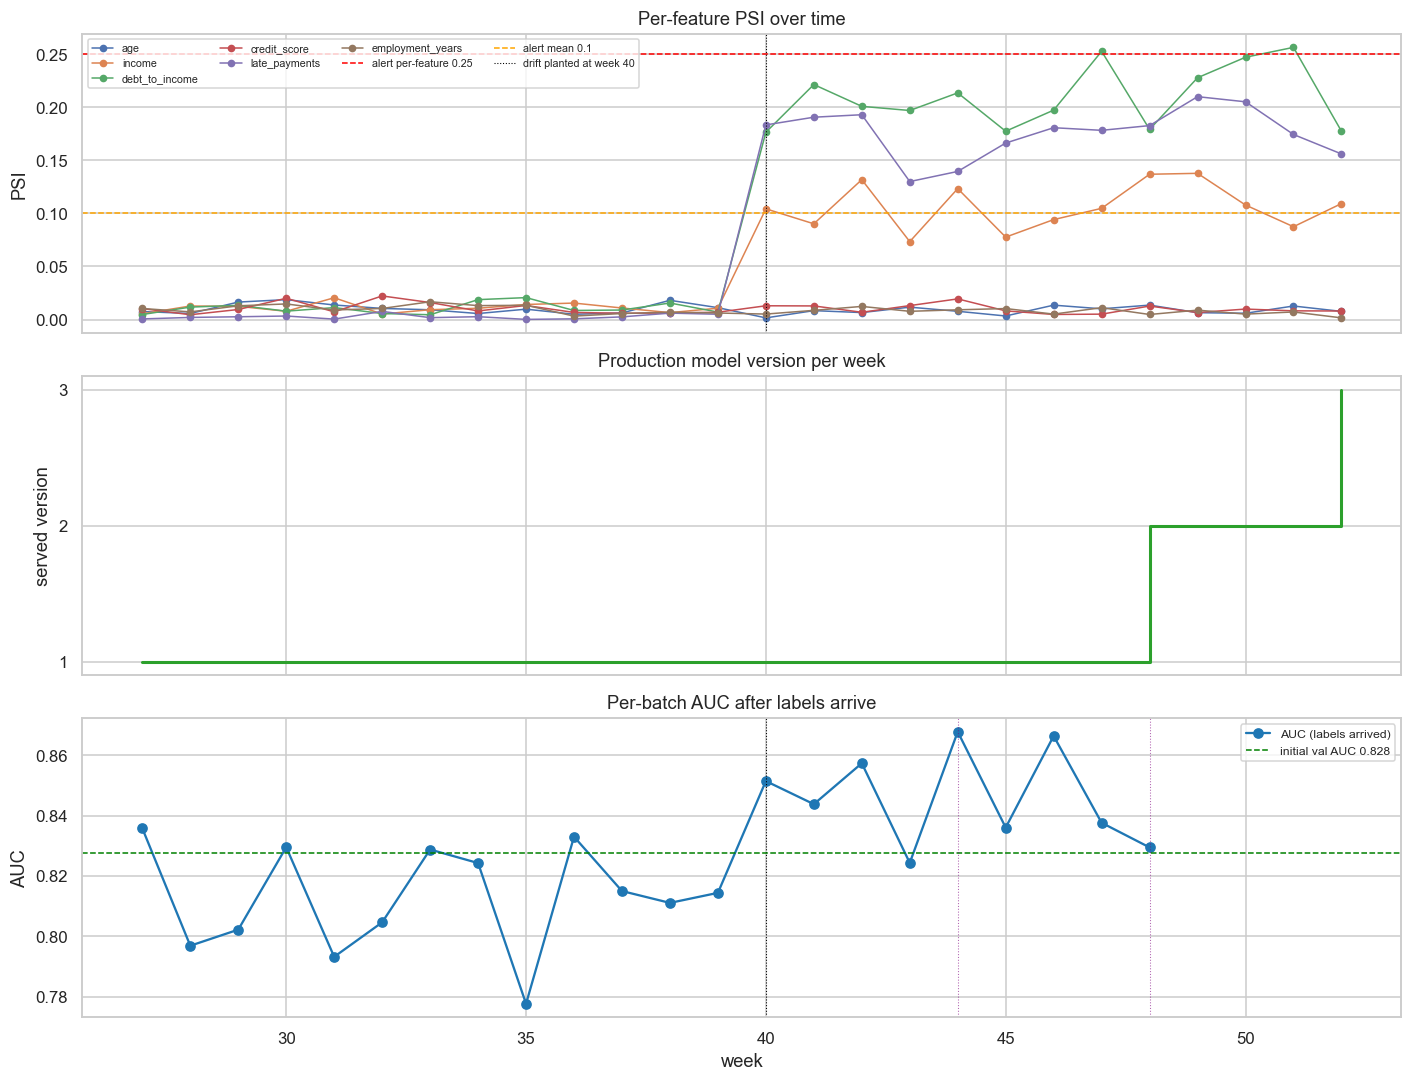

In [13]:
batch_df_log = pd.DataFrame([{
    "week": b.week, "served_version": b.served_version,
    "psi_max": b.psi_max, "psi_mean": b.psi_mean,
    "mean_pred_proba": b.mean_pred_proba,
    "auc": b.auc_when_labels_arrive, "ap": b.ap_when_labels_arrive,
    **{f"psi_{f}": b.psi[f] for f in FEATURES}
} for b in batch_log])

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

for f in FEATURES:
    axes[0].plot(batch_df_log["week"], batch_df_log[f"psi_{f}"], marker="o", ms=4, label=f, lw=1)
axes[0].axhline(ALERT_PSI_PER_FEATURE, color="red", ls="--", lw=1, label=f"alert per-feature {ALERT_PSI_PER_FEATURE}")
axes[0].axhline(ALERT_PSI_MEAN, color="orange", ls="--", lw=1, label=f"alert mean {ALERT_PSI_MEAN}")
axes[0].axvline(DRIFT_WEEK, color="black", ls=":", lw=0.7, label=f"drift planted at week {DRIFT_WEEK}")
axes[0].set_ylabel("PSI"); axes[0].set_title("Per-feature PSI over time")
axes[0].legend(fontsize=7, ncol=4, loc="upper left")

axes[1].step(batch_df_log["week"], batch_df_log["served_version"], where="post", color="#2ca02c", lw=2)
axes[1].set_ylabel("served version"); axes[1].set_title("Production model version per week")
axes[1].set_yticks(sorted(batch_df_log["served_version"].unique()))

mask = batch_df_log["auc"].notna()
axes[2].plot(batch_df_log.loc[mask, "week"], batch_df_log.loc[mask, "auc"], marker="o", color="#1f77b4", lw=1.5, label="AUC (labels arrived)")
axes[2].axvline(DRIFT_WEEK, color="black", ls=":", lw=0.7)
axes[2].axhline(best_val_auc, color="green", ls="--", lw=1, label=f"initial val AUC {best_val_auc:.3f}")
for r in retrain_log:
    axes[2].axvline(r.get("ab_eval_week", 0) + LABEL_LAG_WEEKS, color="purple", ls=":", lw=0.7, alpha=0.6)
axes[2].set_xlabel("week"); axes[2].set_ylabel("AUC")
axes[2].set_title("Per-batch AUC after labels arrive")
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

In [14]:
if retrain_log:
    retrain_df = pd.DataFrame([{
        "trigger_week": r.get("ab_eval_week", 0) + LABEL_LAG_WEEKS,
        "candidate_version": r["version"],
        "production_auc": r.get("production_auc_eval", float("nan")),
        "candidate_auc":  r.get("candidate_auc_eval", float("nan")),
        "lift":           r.get("lift", float("nan")),
        "promoted":       r.get("promoted", False),
        "trigger_reason": r["trigger_reason"][:80],
    } for r in retrain_log]).round(4)
    print("Retraining log:")
    print(retrain_df.to_string(index=False))
else:
    print("No retraining triggered (no drift detected — methodology runnable but uninformative).")

Retraining log:
 trigger_week  candidate_version  production_auc  candidate_auc   lift  promoted                           trigger_reason
           44                  2          0.8514         0.9495 0.0981      True max-PSI=0.253 on a feature exceeded 0.25
           48                  3          0.8392         0.9559 0.1167      True max-PSI=0.256 on a feature exceeded 0.25


## 7. Lifecycle audit + production hygiene

The audit JSON is the single artefact a deployment review reads:

- Number of distinct serving versions across the post-deployment window.
- Cumulative AUC under each lifecycle stage.
- Which weeks were served by which version.
- Reasons each retrain was triggered.

Persisted artefacts: the audit JSON, the batch log CSV, and the model card.

In [15]:
audit = {
    "experiment": EXPERIMENT_NAME,
    "tracking_uri": TRACKING_URI,
    "registered_model": REGISTERED_MODEL_NAME,
    "training_window": [1, TRAIN_END_WEEK],
    "post_deployment_window": [TRAIN_END_WEEK + 1, N_WEEKS],
    "drift_planted_at_week": DRIFT_WEEK,
    "alert_thresholds": {
        "per_feature_PSI": ALERT_PSI_PER_FEATURE,
        "mean_PSI": ALERT_PSI_MEAN,
        "consecutive_batches": ALERT_CONSECUTIVE,
        "label_lag_weeks": LABEL_LAG_WEEKS,
        "retrain_window_weeks": RETRAIN_WINDOW_WEEKS,
    },
    "n_initial_sweep_runs": len(SWEEP_CONFIGS),
    "best_initial_val_auc": best_val_auc,
    "n_retrain_events": len(retrain_log),
    "retrain_events": [{
        "trigger_week": int(r.get("ab_eval_week", 0) + LABEL_LAG_WEEKS),
        "trained_through_week": r["trained_through"],
        "candidate_version": int(r["version"]),
        "production_auc_at_trigger": float(r.get("production_auc_eval", float("nan"))),
        "candidate_auc_at_trigger":  float(r.get("candidate_auc_eval", float("nan"))),
        "promoted": bool(r.get("promoted", False)),
        "reason": r["trigger_reason"],
    } for r in retrain_log],
    "served_version_per_week": {int(b.week): int(b.served_version) for b in batch_log},
}

(DATA_DIR / "lifecycle_audit.json").write_text(json.dumps(audit, indent=2))
batch_df_log.to_csv(DATA_DIR / "batch_log.csv", index=False)
print(f"Wrote lifecycle_audit.json")
print(f"Wrote batch_log.csv")
print()
print("Distinct serving versions used over the post-deployment window:",
      sorted(set(b.served_version for b in batch_log)))
print(f"Final production version  : {client.get_model_version_by_alias(REGISTERED_MODEL_NAME, 'production').version}")
print(f"Total MLflow runs logged : {len(client.search_runs(experiment_ids=[exp.experiment_id]))}")

Wrote lifecycle_audit.json
Wrote batch_log.csv

Distinct serving versions used over the post-deployment window: [1, 2, 3]
Final production version  : 3
Total MLflow runs logged : 7


In [16]:
def make_card() -> dict:
    final_prod = client.get_model_version_by_alias(REGISTERED_MODEL_NAME, "production")
    return {
        "name": "mlops_mlflow_drift_lifecycle",
        "version": "1.0.0",
        "task": "credit-risk default prediction with full ML lifecycle: sweep -> registry -> serve -> drift-monitor -> retrain -> A/B promote",
        "data": {
            "source": "synthetic; 50,000 applicants × 52 weekly batches; planted drift at week 40 (income -15%, debt-to-income +30%, late_payments lambda 0.6 -> 1.0)",
            "n_features": int(len(FEATURES)),
            "features": FEATURES,
        },
        "infrastructure": {
            "tracking_uri": TRACKING_URI,
            "experiment_id": exp.experiment_id,
            "registered_model": REGISTERED_MODEL_NAME,
            "current_production_version": int(final_prod.version),
            "n_total_runs": len(client.search_runs(experiment_ids=[exp.experiment_id])),
        },
        "alert_policy": {
            "per_feature_PSI_threshold": ALERT_PSI_PER_FEATURE,
            "mean_PSI_threshold": ALERT_PSI_MEAN,
            "consecutive_batches_for_mean_alert": ALERT_CONSECUTIVE,
            "retrain_window_weeks": RETRAIN_WINDOW_WEEKS,
            "label_lag_weeks": LABEL_LAG_WEEKS,
            "ab_lift_threshold_auc": 0.01,
        },
        "lifecycle_summary": {
            "initial_sweep_best_val_auc": float(best_val_auc),
            "n_retrain_events": len(retrain_log),
            "n_promotions": sum(1 for r in retrain_log if r.get("promoted", False)),
            "served_versions_used": sorted(set(b.served_version for b in batch_log)),
        },
        "intended_use": "Production credit-risk classifier with automated drift response. Methodology transfers verbatim to any tabular-classification task where labels arrive with delay.",
        "limitations": [
            "Drift is in inputs only; concept drift (input -> output relationship change) requires separate monitoring (we recommend tracking the calibration-curve over time).",
            "Local SQLite tracking server — production deployments need a real backend (PostgreSQL + S3-style artefact store) and authentication.",
            "PSI uses 10 quantile bins on training data; alternative binning strategies (decile, equal-width) and KS / Wasserstein distances are complementary signals.",
            "A/B promotion uses single-week holdout; production should use a longer evaluation window plus a paired-bootstrap CI on the AUC lift.",
            "Synthetic data with planted drift; real drift is messier and may require concept-drift-specific detectors (DDM, EDDM, ADWIN on residuals).",
        ],
    }


card = make_card()
card_path = DATA_DIR / "model_card.json"
card_path.write_text(json.dumps(card, indent=2))
print(f"Wrote model card to {card_path}")
print(json.dumps({k: v for k, v in card.items() if k in {"name", "infrastructure", "lifecycle_summary"}}, indent=2))

Wrote model card to C:\Users\diogo\work_code\ds-projects-portfolio\notebooks\artifacts\mlops\model_card.json
{
  "name": "mlops_mlflow_drift_lifecycle",
  "infrastructure": {
    "tracking_uri": "sqlite:///C:/Users/diogo/work_code/ds-projects-portfolio/notebooks/artifacts/mlops/mlflow.db",
    "experiment_id": "1",
    "registered_model": "credit_risk_classifier",
    "current_production_version": 3,
    "n_total_runs": 7
  },
  "lifecycle_summary": {
    "initial_sweep_best_val_auc": 0.8276716709581551,
    "n_retrain_events": 2,
    "n_promotions": 2,
    "served_versions_used": [
      1,
      2,
      3
    ]
  }
}


## 8. Decision memo

**Recommendation.** Adopt the **alert → retrain → A/B → promote** loop as the default operational pattern for tabular classifiers with labelled-with-lag feedback.  Tune the thresholds per use case but keep the decomposition: **drift detection is separate from concept-drift monitoring**, **A/B comparison is separate from drift**, **promotion is separate from registration**.

**Why this decomposition.**

- **Drift detection** answers "are the *inputs* still in distribution?" — purely on serving-time features, no labels needed.  Cheap, fast, runs every batch.
- **Concept-drift monitoring** answers "is the *input → output* relationship the same?" — requires labels.  Slower (label lag) but the only signal that catches input-stable / relationship-shift events (e.g., underwriting policy change).  Add this notebook would extend with a calibration-curve-over-time chart; we left it as an extension.
- **A/B comparison** answers "would the candidate actually beat the incumbent?" — drift fires triggers, but only an A/B test on labelled holdout decides promotion.  Skipping A/B is the most common production failure mode (alert → blind retrain → silently worse model in prod).
- **Promotion** is a single registry write: alias `production` to the new version.  Atomic, instant, reversible.  Downstream code reads `models:/credit_risk@production` and is unaware of the swap.

**Threshold-tuning rules.**

- **PSI thresholds**: 0.10 / 0.25 are standard but feature-specific.  For features with *high* training variance the same PSI corresponds to less-meaningful change; consider per-feature thresholds derived from a backtest.
- **Consecutive-batch requirement**: prevents single-batch noise from triggering retrains.  Two is conservative; one is sensitive; three+ is sluggish.
- **A/B lift threshold**: 0.01 AUC is a defensible default for credit-risk; for models with structurally noisier holdouts (small-sample text, rare-event detection) raise to 0.02 or use a paired-bootstrap CI.

**Operational contracts.**

1. Every `production` model version has a logged training run with the data window in tags.  *Always.*  The single most useful audit artefact is "what data did the currently-serving model see?".
2. The `production` alias is **never** set without an A/B test on labelled holdout; the lift threshold is part of the model card.
3. The drift dashboard is **public to the product team**, not just to ML.  Drift is a business signal as much as a technical one.

**What I would do next.**

1. **Concept-drift monitoring** — calibration-curve-over-time + bootstrap CI on the calibration intercept; complement to PSI.
2. **Slice-aware drift** — PSI per important slice (region, channel, segment); a portfolio-level mean PSI can hide a critical-segment shift.
3. **Shadow deployment** — score every batch with both production *and* the latest candidate, store both predictions, run paired-bootstrap A/B every week.  Removes the "trigger-reactive" pattern in favour of a continuous comparison.
4. **Retraining cadence learning** — log retraining-events vs business KPI (loss rate, conversion, ...) and learn the cadence that minimises business KPI drift without chasing input-PSI noise.

## 9. Limitations and next steps

**Data.**

- Synthetic with controlled drift — methodology transfers verbatim, but absolute numbers (drift onset, retrain efficacy) are dataset-specific.
- 1,000 applicants per week — small for narrow CIs on per-batch AUC; production volumes give tighter signal.
- Only **input drift**, not **concept drift**.  A real recession would shift both inputs *and* the input → output relationship; the latter requires labelled-feedback monitoring.

**Methodology.**

- **PSI binning** uses 10 quantile bins on the training distribution; alternative binnings shift sensitivities.  KS test / Wasserstein distance / energy distance are complementary; combining them via a meta-score is the production fix.
- **Single A/B holdout week** — production should use a longer holdout and paired-bootstrap or **DM test** for significance.  We use the simpler 0.01-AUC-lift rule for clarity.
- **Retrain configuration is fixed** to the median-of-sweep config; in production the candidate would itself be a small sweep, with the best run promoted.

**Infrastructure.**

- **Local SQLite tracking** is for portability.  Production uses PostgreSQL + S3-style artefact store + authentication / authorisation.
- **No CI/CD** — the notebook does the loop interactively.  In production this is a scheduled DAG (Airflow / Prefect / Dagster) with the same MLflow calls behind it.
- **No serving layer** — we score in-notebook.  A real service wraps the model behind an API (FastAPI per-request, or batch via a job).  See `genai_service_delivery.ipynb` for the inference-API pattern.

**Monitoring.**

- We monitor **PSI** and **AUC** but not **calibration**.  A drifted model can preserve AUC (rank order) while losing calibration (the predicted-probability scale).  In credit risk this matters for capital calculations.  Track ECE / Brier / calibration-curve slope per batch.
- We do not monitor **fairness slices** — the same drift that triggers a retrain can change subgroup performance.  Tracking PSI + AUC + calibration *per slice* is the production extension.